AI Lab

In [1]:
 pip install requests

In [6]:
import requests

In [7]:
h= requests.get('https://www.kaggle.com/crawford/gene-expression/downloads/actual.csv')

In [8]:
d=h.content
csvfile=open('download.csv','wb')
csvfile.write(d)


4918

In [9]:
url = 'http://google.com/favicon.ico'
r = requests.get(url, allow_redirects=True)
open('google.ico', 'wb').write(r.content)
r = requests.get(url, allow_redirects=True)
print(r.headers.get('content-type'))


image/x-icon


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt


In [12]:
!pip install google-auth google-auth-oauthlib google-auth-httplib2 googleapiclient


ERROR: Could not find a version that satisfies the requirement googleapiclient (from versions: none)
ERROR: No matching distribution found for googleapiclient


In [14]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [15]:
import requests

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'  # Replace with dataset URL
response = requests.get(url)

with open('diabetes.csv', 'wb') as file:
    file.write(response.content)

print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [16]:
import pandas as pd

df = pd.read_csv('diabetes.csv', header=None)  # Modify based on your dataset
df.head()


,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, header=None)
df.head()


,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
import requests

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'  # Replace with dataset URL
response = requests.get(url)

with open('diabetes.csv', 'wb') as file:
    file.write(response.content)

print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [20]:
import numpy as np

# Check for missing values
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(df.mean(), inplace=True) 

# Convert categorical variables if necessary
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df.iloc[:, -1] = label_encoder.fit_transform(df.iloc[:, -1])  # Encoding the last column if categorical


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1]  # Features (all columns except the last)
y = df.iloc[:, -1]   # Target variable (last column)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")


Training set shape: (537, 8), Testing set shape: (231, 8)


In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the model
mlp = MLPClassifier(hidden_layer_sizes=(8,8,8), activation='relu', solver='adam', max_iter=600)
mlp.fit(X_train, y_train)

# Predictions
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

# Performance Evaluation
print("Training Performance:\n", classification_report(y_train, y_train_pred))
print("Testing Performance:\n", classification_report(y_test, y_test_pred))


Training Performance:
               precision    recall  f1-score   support

           0       0.87      0.88      0.88       343
           1       0.79      0.77      0.78       194

    accuracy                           0.84       537
   macro avg       0.83      0.83      0.83       537
weighted avg       0.84      0.84      0.84       537

Testing Performance:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       157
           1       0.63      0.57      0.60        74

    accuracy                           0.75       231
   macro avg       0.72      0.70      0.71       231
weighted avg       0.75      0.75      0.75       231



C:\Users\91705\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the regression model
mlp_reg = MLPRegressor(hidden_layer_sizes=(8,8,8), activation='relu', solver='adam', max_iter=500)
mlp_reg.fit(X_train, y_train)

# Predictions
y_pred_train = mlp_reg.predict(X_train)
y_pred_test = mlp_reg.predict(X_test)

# Performance Metrics
print("Mean Squared Error (Test):", mean_squared_error(y_test, y_pred_test))
print("Root Mean Squared Error (Test):", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2 Score:", r2_score(y_test, y_pred_test))


Mean Squared Error (Test): 0.18058025846123615
Root Mean Squared Error (Test): 0.42494735963556257
R2 Score: 0.17060224033826632


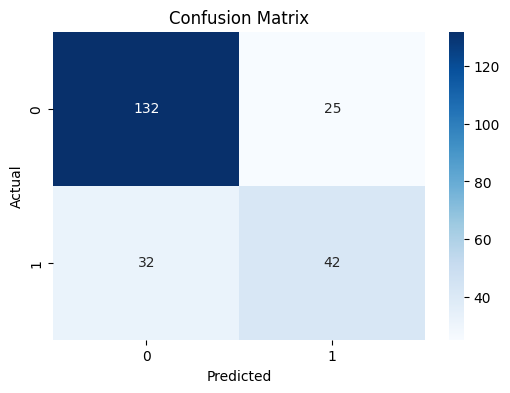

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


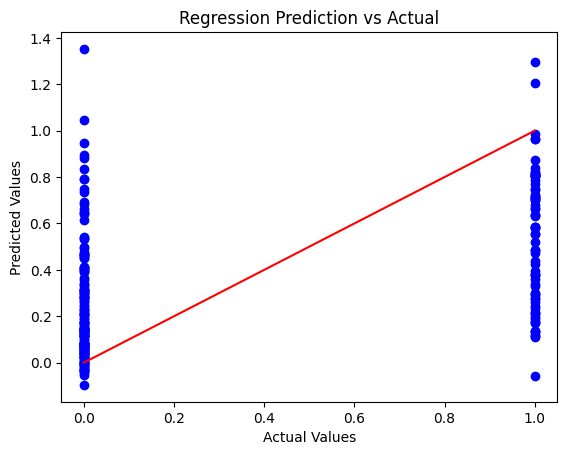

In [25]:
plt.scatter(y_test, y_pred_test, color='blue')
plt.plot(y_test, y_test, color='red')  # Ideal regression line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Regression Prediction vs Actual")
plt.show()


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

In [27]:
def unitStep(x):
    return 1 if x >= 0 else 0

In [28]:
def perceptron_train(X, y, epochs=20, lr=0.1):
    w = np.zeros(X.shape[1])  # Initialize weights
    b = 0  # Bias term
    
    for epoch in range(epochs):
        for i in range(len(X)):
            y_pred = unitStep(np.dot(X[i], w) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]  # Update weights
            b += lr * error  # Update bias
            
    return w, b 

In [29]:
def plot_decision_boundary(w, b, X, y, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")

    # Generate a decision boundary
    x_vals = np.linspace(-0.1, 1.1, 100)
    y_vals = (-b - w[0] * x_vals) / w[1]
    plt.plot(x_vals, y_vals, 'r', label="Decision Boundary")

    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [30]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])

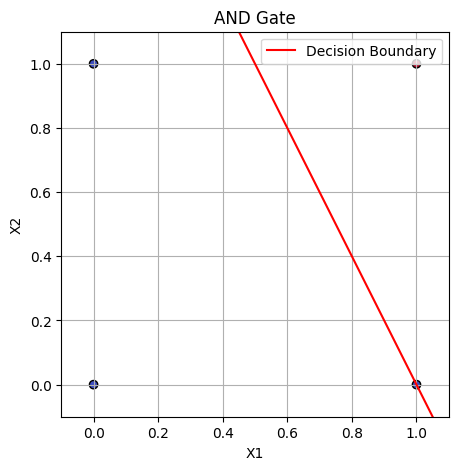

In [31]:
y_AND = np.array([0, 0, 0, 1])
w_AND, b_AND = perceptron_train(X, y_AND)
plot_decision_boundary(w_AND, b_AND, X, y_AND, "AND Gate")


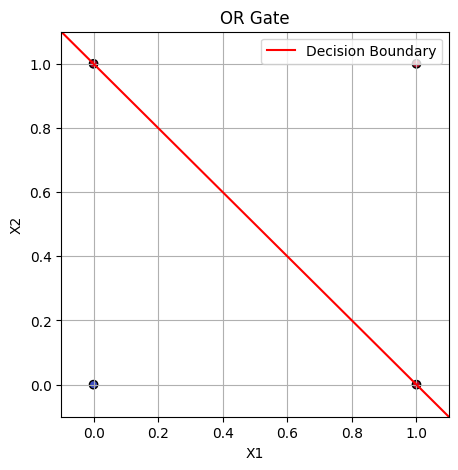

In [32]:
y_OR = np.array([0, 1, 1, 1])
w_OR, b_OR = perceptron_train(X, y_OR)
plot_decision_boundary(w_OR, b_OR, X, y_OR, "OR Gate")

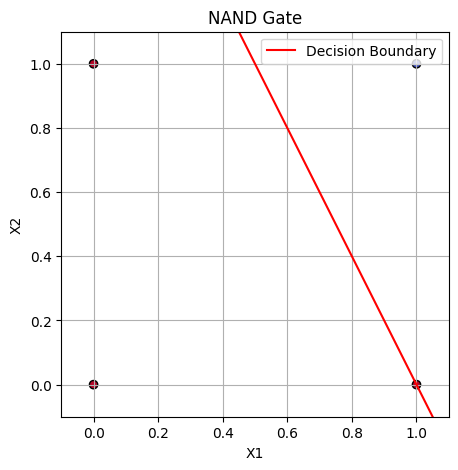

In [33]:
y_NAND = np.array([1, 1, 1, 0])
w_NAND, b_NAND = perceptron_train(X, y_NAND)
plot_decision_boundary(w_NAND, b_NAND, X, y_NAND, "NAND Gate")


In [34]:
mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', solver='adam', max_iter=1000)
y_XOR = np.array([0, 1, 1, 0])  # XOR Truth Table
mlp.fit(X, y_XOR)

C:\Users\91705\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(4,), max_iter=1000)

In [35]:
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 100), np.linspace(-0.1, 1.1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict(grid).reshape(xx.shape)

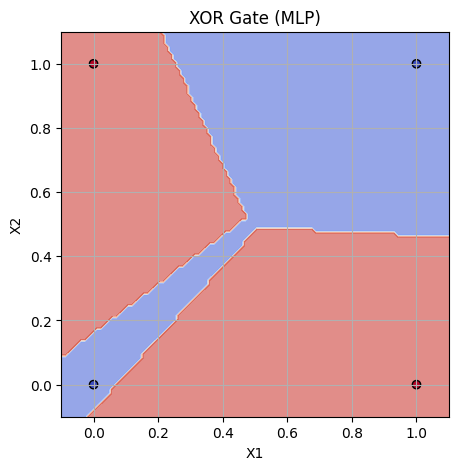

In [36]:
plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y_XOR, cmap="coolwarm", edgecolors="k")
plt.title("XOR Gate (MLP)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid()
plt.show()